In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

#Softmax Function

In [29]:
def softmax(z):
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

#Prediction function


In [30]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

#Loss & Cost Function

In [38]:
def loss_softmax(y_pred, y):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.sum(y * np.log(y_pred)) / y.shape[0]


def cost_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return -np.sum(y * np.log(y_pred)) / n

Gradient Function

In [33]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

Gradient Descent

In [39]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

In [34]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    classes = np.unique(y)

    for i, digit in enumerate(classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.show()


def load_and_prepare_mnist(csv_file):
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values / 255.0

    plot_sample_images(X, y)

    return train_test_split(X, y, test_size=0.2, random_state=42)

Load data

In [40]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    classes = np.unique(y)

    for i, digit in enumerate(classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.show()


def load_and_prepare_mnist(csv_file):
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values / 255.0

    plot_sample_images(X, y)

    return train_test_split(X, y, test_size=0.2, random_state=42)

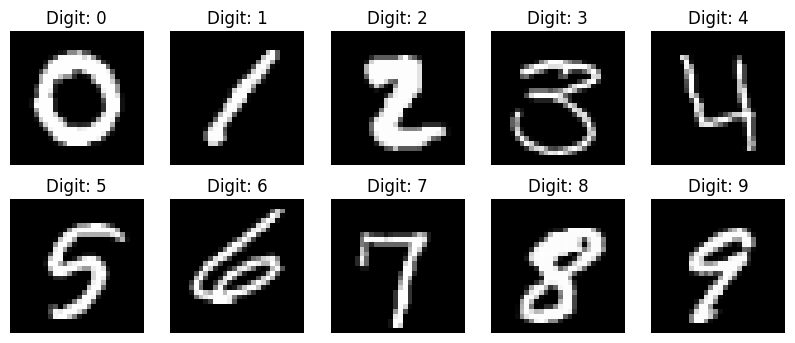

In [41]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("/content/mnist_train.csv")

In [42]:
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

In [43]:
d = X_train.shape[1]   # features
c = y_train.shape[1]   # classes

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

In [45]:
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b,
    alpha=0.1,
    n_iter=1000
)

Iteration 0, Cost: 2.1938
Iteration 100, Cost: 0.6001
Iteration 200, Cost: 0.4817
Iteration 300, Cost: 0.4325
Iteration 400, Cost: 0.4040
Iteration 500, Cost: 0.3848
Iteration 600, Cost: 0.3707
Iteration 700, Cost: 0.3598
Iteration 800, Cost: 0.3510
Iteration 900, Cost: 0.3437


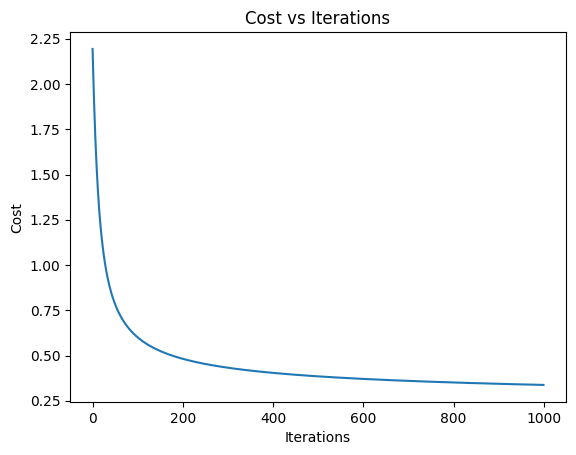

In [46]:
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

Evaluation

In [47]:
y_pred = predict_softmax(X_test, W_opt, b_opt)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

Confusion Matrix:
 [[778   0   1   1   3  13   8   0  11   1]
 [  1 889   2   1   1   1   2   2   9   1]
 [  6  10 735  14  25   2  12  16  25   1]
 [  2   5  27 799   1  40   6  12  27  18]
 [  1   1   8   2 773   4  11   2   2  35]
 [ 10   6   5  25  15 586  22   4  21   8]
 [  7   1   7   3   6   9 741   1   9   1]
 [  1  12  17   3  14   4   0 803   2  37]
 [  2  12   9  26   7  24   8   7 728  12]
 [  6   3   6  16  24   7   0  30   6 740]]
Precision: 0.901295268395501
Recall: 0.9014285714285715
F1 Score: 0.9011717201485799
